In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

# Validación temporal y tuning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

%matplotlib inline
%config IPCompleter.greedy=True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga del dataset

Fuente: registros de importación de SUNAT/Aduanas correspondientes a la
subpartida nacional 4011 (neumáticos nuevos de caucho), vía marítima,
ingresados por la Aduana Marítima del Callao desde origen asiático.
El archivo `resultado_combinado.csv` consolida los registros del período 2021–2025.

In [3]:
dataframe = pd.read_csv(
    '/content/drive/MyDrive/TP1/Dataset/resultado_combinado.csv',
    sep=',',
    quotechar='"',
    encoding='utf-8',
    low_memory=False
)

print(f'Filas: {dataframe.shape[0]:,}  |  Columnas: {dataframe.shape[1]}')
dataframe.head()

Filas: 86,977  |  Columnas: 30


,CNAN,DESCRIP,FECHA,CADUANA,ADUA_DESC,CPAIS,PAIS_DESC,FOB_DOLPOL,FLE_DOLAR,SEG_DOLAR,...,NUME_SERIE,VIA_TRANSP,VIAT_DESC,SEST_MERCA,SEST_DESC,TIPO_DOCUM,LIBR_TRIBU,IMPORTADOR,CPAIS_PROC,DPAIS_PROC
0,4011101000,- - Radiales\t,20250102,118,MARITIMA DEL CALLAO,CN,CHINA,2214.64,273.62,33.22,...,1,1,MARITIMO,10,NUEVO/BUENO,4,20140441083,TIRE SOL S.A.C.,CN,CHINA
1,4011101000,- - Radiales\t,20250102,118,MARITIMA DEL CALLAO,CN,CHINA,1620.00,200.16,24.30,...,2,1,MARITIMO,10,NUEVO/BUENO,4,20140441083,TIRE SOL S.A.C.,CN,CHINA
2,4011101000,- - Radiales\t,20250102,118,MARITIMA DEL CALLAO,CN,CHINA,3785.40,467.70,56.78,...,3,1,MARITIMO,10,NUEVO/BUENO,4,20140441083,TIRE SOL S.A.C.,CN,CHINA
3,4011101000,- - Radiales\t,20250102,118,MARITIMA DEL CALLAO,CN,CHINA,1475.40,182.29,22.13,...,4,1,MARITIMO,10,NUEVO/BUENO,4,20140441083,TIRE SOL S.A.C.,CN,CHINA
4,4011101000,- - Radiales\t,20250102,118,MARITIMA DEL CALLAO,CN,CHINA,4312.00,532.76,64.68,...,16,1,MARITIMO,10,NUEVO/BUENO,4,20140441083,TIRE SOL S.A.C.,CN,CHINA


## 2. Normalización de tipos y filtros de alcance

`FECHA` se almacena como entero `AAAAMMDD` y se convierte a tipo fecha real para
permitir el análisis temporal. `CNAN` se trata como código (cadena), no como número.

Los filtros de alcance dejan explícito el universo de estudio (subpartida 4011,
transporte marítimo, Aduana del Callao, origen asiático). En este dataset ya vienen
prefiltrados, pero se documentan para garantizar la reproducibilidad ante una
eventual recarga con datos más amplios.

In [4]:
# Tipos
dataframe['FECHA'] = pd.to_datetime(dataframe['FECHA'], format='%Y%m%d', errors='coerce')
dataframe['CNAN']  = dataframe['CNAN'].astype(str).str.zfill(10)

# Filtros de alcance (salvaguarda documental)
paises_asia = ['CN','TH','VN','KR','JP','ID','MY','IN','SG','PH','HK','TW']
mask = (
    dataframe['CNAN'].str.startswith('4011') &
    (dataframe['VIA_TRANSP'] == 1) &
    (dataframe['ADUA_DESC'].str.upper().str.contains('CALLAO', na=False)) &
    (dataframe['CPAIS'].isin(paises_asia))
)
df_scope = dataframe.loc[mask].copy()

print(f'Filas antes del filtro: {len(dataframe):,}')
print(f'Filas tras el filtro:   {len(df_scope):,}')
print(f'Filas eliminadas:       {len(dataframe) - len(df_scope):,}')

Filas antes del filtro: 86,977
Filas tras el filtro:   86,977
Filas eliminadas:       0


## 3. Definición de la variable objetivo

El objetivo del modelo es predecir el **flete marítimo unitario** (USD/kg),
definido como `FLE_DOLAR / PESO_NETO`. Se prefiere el flete unitario sobre el
flete absoluto porque normaliza el costo respecto al tamaño del embarque, evita
que el modelo aprenda la relación trivial "mayor peso → mayor flete" y produce
una variable comparable entre importaciones de distinto volumen.

In [5]:
df = df_scope.copy()
df['FLETE_UNIT'] = df['FLE_DOLAR'] / df['PESO_NETO']

print(f'Período: {df["FECHA"].min().date()} → {df["FECHA"].max().date()}')
print(f'Importadores únicos: {df["IMPORTADOR"].nunique()}')

print('\n--- FLE_DOLAR (USD) ---')
print(df['FLE_DOLAR'].describe())

print('\n--- FLETE_UNIT (USD/kg) ---')
print(df['FLETE_UNIT'].describe())

Período: 2021-01-04 → 2025-12-31
Importadores únicos: 167

--- FLE_DOLAR (USD) ---
count     86977.000000
mean        398.220546
std        1062.556530
min           0.090000
25%          56.740000
50%         142.310000
75%         367.570000
max      135000.000000
Name: FLE_DOLAR, dtype: float64

--- FLETE_UNIT (USD/kg) ---
count    86977.000000
mean         0.427340
std          0.405136
min          0.022286
25%          0.173378
50%          0.263207
75%          0.618327
max         17.098640
Name: FLETE_UNIT, dtype: float64


## 4. Análisis exploratorio (EDA)

### 4.1 Distribución del objetivo
Ambas variables presentan fuerte sesgo a la derecha, característico de variables
económicas de costo. Esto motiva el uso de métodos de detección de atípicos
robustos al sesgo (sección 5).

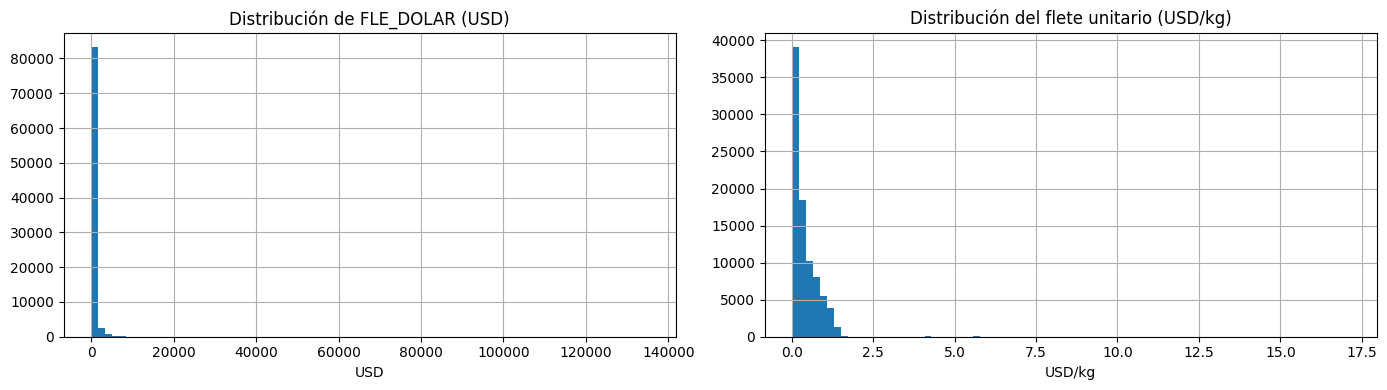

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['FLE_DOLAR'].hist(bins=80, ax=axes[0])
axes[0].set_title('Distribución de FLE_DOLAR (USD)')
axes[0].set_xlabel('USD')
df['FLETE_UNIT'].hist(bins=80, ax=axes[1])
axes[1].set_title('Distribución del flete unitario (USD/kg)')
axes[1].set_xlabel('USD/kg')
plt.tight_layout(); plt.show()

### 4.2 Evolución temporal del flete
La serie mensual evidencia la crisis de fletes 2021–2022 (pico cercano a
1.2 USD/kg a fines de 2021) y la posterior normalización hacia 2025 (~0.17 USD/kg).
Esta dinámica de mercado, ajena a las características del envío, es la principal
fuente de variación del flete y justifica la incorporación de variables externas.

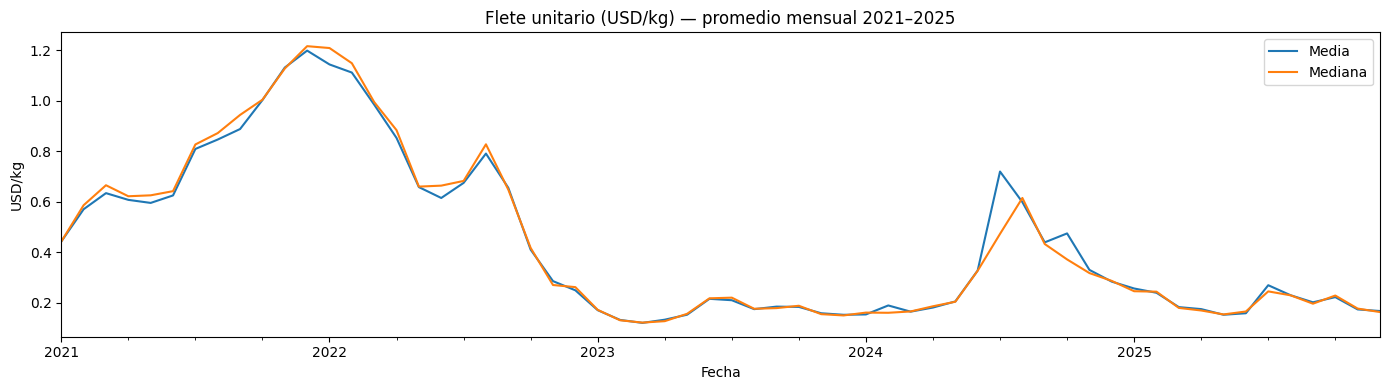

In [7]:
serie = (df.set_index('FECHA')['FLETE_UNIT']
           .resample('ME')
           .agg(['mean','median','count']))

fig, ax = plt.subplots(figsize=(14, 4))
serie['mean'].plot(ax=ax, label='Media')
serie['median'].plot(ax=ax, label='Mediana')
ax.set_title('Flete unitario (USD/kg) — promedio mensual 2021–2025')
ax.set_ylabel('USD/kg'); ax.set_xlabel('Fecha'); ax.legend()
plt.tight_layout(); plt.show()

### 4.3 Distribución anual (boxplot)
El boxplot por año resume en una sola figura la caída sostenida del flete y la
contracción de su dispersión tras la normalización del mercado.

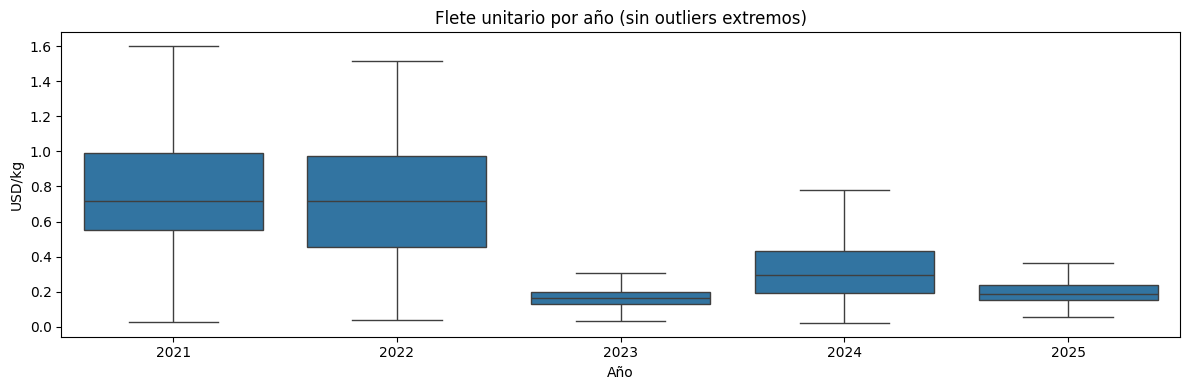

In [8]:
df['ANIO'] = df['FECHA'].dt.year
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df, x='ANIO', y='FLETE_UNIT', showfliers=False, ax=ax)
ax.set_title('Flete unitario por año (sin outliers extremos)')
ax.set_ylabel('USD/kg'); ax.set_xlabel('Año')
plt.tight_layout(); plt.show()

### 4.4 Correlación con variables internas
La matriz de correlación muestra que el flete unitario presenta correlaciones
prácticamente nulas con las variables internas del envío (peso, valor FOB,
cantidad). Esto confirma que la predicción no puede sustentarse solo en atributos
del embarque y refuerza la necesidad de variables temporales y de mercado.

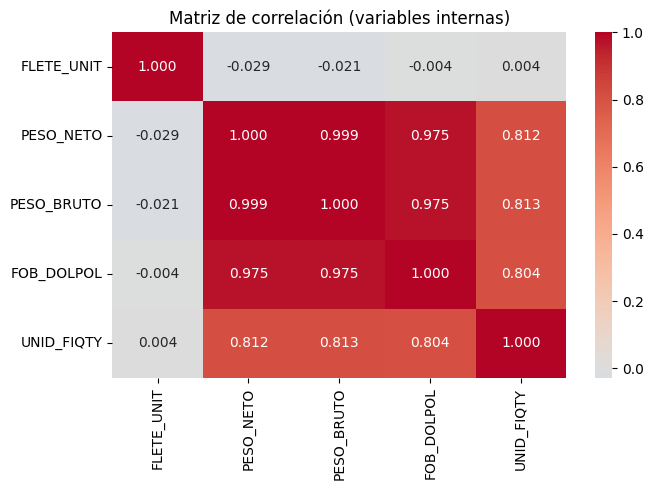

Correlación con el objetivo:
FLETE_UNIT    1.000000
UNID_FIQTY    0.003718
FOB_DOLPOL   -0.003958
PESO_BRUTO   -0.021260
PESO_NETO    -0.028512
Name: FLETE_UNIT, dtype: float64


In [9]:
num_cols = ['FLETE_UNIT','PESO_NETO','PESO_BRUTO','FOB_DOLPOL','UNID_FIQTY']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación (variables internas)')
plt.tight_layout(); plt.show()

print('Correlación con el objetivo:')
print(corr['FLETE_UNIT'].sort_values(ascending=False))

### 4.5 Concentración por puerto de embarque e importador
El puerto de embarque y el importador son candidatos a variables categóricas
predictoras. Qingdao concentra la mayor parte de los embarques.

In [10]:
print('Top 8 puertos de embarque:')
print(df['PUER_DESC'].value_counts().head(8))

print('\nTop 10 importadores:')
print(df['IMPORTADOR'].value_counts().head(10))

Top 8 puertos de embarque:
PUER_DESC
QINGDAO     69265
SHANGHAI     4373
SHEKOU       3077
NINGBO       1519
XIAMEN       1409
BUSAN        1015
YANTIAN       830
DALIAN        768
Name: count, dtype: int64

Top 10 importadores:
IMPORTADOR
TIRE SOL S.A.C.                             13662
STEELS ASOCIADOS S.A.C.                     10919
J.CH.COMERCIAL S.A.                         10564
No Disponible - Ley 29733                    5881
LLANMAXXI DEL PERU S.A.C.                    5878
ZONA LLANTAS S.A.C.                          3536
COMERCIAL YUAN DA 168 S.A.C.                 2912
EMOTION GROUP PERU SOCIEDAD ANONIMA CERR     2842
CASOLI S.A.C.                                2779
LA CASA DEL NEUMATICO EMPRESA INDIVIDUAL     2598
Name: count, dtype: int64


## 5. Detección y tratamiento de atípicos

Dado el fuerte sesgo del flete unitario, el rango intercuartílico clásico produce
límites inferiores negativos, inválidos para una variable estrictamente positiva.
Se adopta un recorte por **percentiles P0.5–P99.5**, que descarta el 1% extremo
atribuible a errores de registro o consolidaciones atípicas, sin asumir normalidad.

In [11]:
p_low, p_high = df['FLETE_UNIT'].quantile([0.005, 0.995])
print(f'Límite inferior (P0.5):  {p_low:.4f} USD/kg')
print(f'Límite superior (P99.5): {p_high:.4f} USD/kg')

n_out = ((df['FLETE_UNIT'] < p_low) | (df['FLETE_UNIT'] > p_high)).sum()
print(f'Atípicos a descartar: {n_out:,} ({100*n_out/len(df):.2f}%)')

Límite inferior (P0.5):  0.0676 USD/kg
Límite superior (P99.5): 1.4669 USD/kg
Atípicos a descartar: 870 (1.00%)


## 6. Dataset depurado

Se aplica el recorte de atípicos y se eliminan duplicados y registros con flete
no positivo (salvaguardas; en este dataset no remueven filas). El resultado es
`df_clean`, base para el feature engineering y el modelado.

In [12]:
df_clean = df[(df['FLETE_UNIT'] >= p_low) & (df['FLETE_UNIT'] <= p_high)].copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean['FLE_DOLAR'] > 0]
df_clean = df_clean.sort_values('FECHA').reset_index(drop=True)

print(f'Filas antes:   {len(df):,}')
print(f'Filas después: {len(df_clean):,}')
print(f'Eliminadas:    {len(df) - len(df_clean):,}')
print('\nResumen del objetivo depurado (FLETE_UNIT):')
print(df_clean['FLETE_UNIT'].describe())

Filas antes:   86,977
Filas después: 86,107
Eliminadas:    870

Resumen del objetivo depurado (FLETE_UNIT):
count    86107.000000
mean         0.416547
std          0.327097
min          0.067648
25%          0.173731
50%          0.263207
75%          0.612060
max          1.466945
Name: FLETE_UNIT, dtype: float64


## 7. Ingeniería de características

A partir del hallazgo de la sección 4.4 (las variables internas del envío no
explican el flete unitario), la estrategia de features se centra en tres ejes:

1. **Temporales**: capturan el régimen de mercado y la estacionalidad.
2. **Rezagos del mercado (lags)**: nivel promedio del flete en meses previos,
   principal señal predictiva dado el comportamiento autorregresivo de la serie.
3. **Categóricas**: puerto de embarque e importador, mediante codificación por
   frecuencia (apropiada ante alta cardinalidad: 167 importadores).

Las variables externas de mercado (SCFI, precio de combustible marítimo,
tipo de cambio SOL/USD) se integran en la sección 8.

In [13]:
fe = df_clean.copy()

# Componentes temporales
fe['anio']        = fe['FECHA'].dt.year
fe['mes']         = fe['FECHA'].dt.month
fe['trimestre']   = fe['FECHA'].dt.quarter
fe['semana_anio'] = fe['FECHA'].dt.isocalendar().week.astype(int)
fe['dia_anio']    = fe['FECHA'].dt.dayofyear

# Codificación cíclica del mes (preserva continuidad dic→ene)
fe['mes_sin'] = np.sin(2 * np.pi * fe['mes'] / 12)
fe['mes_cos'] = np.cos(2 * np.pi * fe['mes'] / 12)

print('Features temporales creadas:')
print(fe[['FECHA','anio','mes','trimestre','semana_anio','mes_sin','mes_cos']].head())

Features temporales creadas:
       FECHA  anio  mes  trimestre  semana_anio  mes_sin   mes_cos
0 2021-01-04  2021    1          1            1      0.5  0.866025
1 2021-01-04  2021    1          1            1      0.5  0.866025
2 2021-01-04  2021    1          1            1      0.5  0.866025
3 2021-01-04  2021    1          1            1      0.5  0.866025
4 2021-01-04  2021    1          1            1      0.5  0.866025


### 7.1 Rezagos del nivel de flete del mercado

Se calcula el flete unitario promedio mensual del mercado y se incorporan sus
rezagos de 1, 2 y 3 meses, junto con una media móvil de 3 meses. Cada registro
recibe únicamente información de meses **anteriores** a su fecha, por lo que no
existe fuga de información (la media del propio mes no se utiliza como predictor).
Estas variables reflejan el estado reciente del mercado, conocido al momento de
estimar un nuevo flete.

In [14]:
# Serie mensual del mercado (promedio de flete unitario por mes)
fe['periodo'] = fe['FECHA'].dt.to_period('M')
serie_mes = fe.groupby('periodo')['FLETE_UNIT'].mean().sort_index()

# Rezagos y media móvil (sobre meses previos -> sin fuga)
lags = pd.DataFrame({'mercado_mean': serie_mes})
lags['mercado_lag1'] = lags['mercado_mean'].shift(1)
lags['mercado_lag2'] = lags['mercado_mean'].shift(2)
lags['mercado_lag3'] = lags['mercado_mean'].shift(3)
lags['mercado_ma3']  = lags['mercado_mean'].shift(1).rolling(3).mean()

# Unir al dataset por periodo (cada fila toma los lags de su mes)
fe = fe.merge(
    lags[['mercado_lag1','mercado_lag2','mercado_lag3','mercado_ma3']],
    left_on='periodo', right_index=True, how='left'
)

print('Rezagos del mercado (primeros meses tendrán NaN por falta de historia):')
print(lags.head(6))
print(f'\nFilas con NaN en lags: {fe["mercado_lag3"].isna().sum():,}')

Rezagos del mercado (primeros meses tendrán NaN por falta de historia):
         mercado_mean  mercado_lag1  mercado_lag2  mercado_lag3  mercado_ma3
periodo                                                                     
2021-01      0.440570           NaN           NaN           NaN          NaN
2021-02      0.579774      0.440570           NaN           NaN          NaN
2021-03      0.626272      0.579774      0.440570           NaN          NaN
2021-04      0.600068      0.626272      0.579774      0.440570     0.548872
2021-05      0.602115      0.600068      0.626272      0.579774     0.602038
2021-06      0.632464      0.602115      0.600068      0.626272     0.609485

Filas con NaN en lags: 3,827


### 7.2 Codificación de variables categóricas por frecuencia

El puerto de embarque y el importador se codifican por frecuencia (proporción de
registros asociados a cada categoría). Frente a la codificación one-hot, evita la
explosión dimensional (167 importadores) y entrega una señal de relevancia de cada
categoría sin asumir orden.

In [15]:
# Frequency encoding (proporción sobre el total)
for col, newcol in [('PUER_DESC','puerto_freq'), ('IMPORTADOR','importador_freq')]:
    freq = fe[col].value_counts(normalize=True)
    fe[newcol] = fe[col].map(freq)

print(fe[['PUER_DESC','puerto_freq','IMPORTADOR','importador_freq']].head())

  PUER_DESC  puerto_freq       IMPORTADOR  importador_freq
0    BALBOA     0.006713  JOSACO E.I.R.L.          0.00763
1    BALBOA     0.006713  JOSACO E.I.R.L.          0.00763
2    BALBOA     0.006713  JOSACO E.I.R.L.          0.00763
3    BALBOA     0.006713  JOSACO E.I.R.L.          0.00763
4    BALBOA     0.006713  JOSACO E.I.R.L.          0.00763


### 7.3 Variables físicas del envío

Aunque las variables internas no se correlacionan individualmente con el flete,
se conservan algunas en forma derivada (densidad de carga y relación peso bruto/neto)
por su potencial valor en interacciones no lineales que los modelos basados en
árboles pueden capturar.

In [16]:
fe['densidad_carga']    = fe['PESO_NETO'] / fe['UNID_FIQTY'].replace(0, np.nan)
fe['ratio_bruto_neto']  = fe['PESO_BRUTO'] / fe['PESO_NETO'].replace(0, np.nan)

# Imputar posibles NaN de las divisiones con la mediana
for c in ['densidad_carga','ratio_bruto_neto']:
    fe[c] = fe[c].fillna(fe[c].median())

print(fe[['PESO_NETO','UNID_FIQTY','densidad_carga','ratio_bruto_neto']].describe())

           PESO_NETO    UNID_FIQTY  densidad_carga  ratio_bruto_neto
count   86107.000000  86107.000000    86107.000000      86107.000000
mean      979.624990     97.256866       13.055058          1.024197
std      1791.821366    202.263170       14.599144          0.080210
min         0.410000      1.000000        0.079333          1.000000
25%       217.740000     20.000000        7.299906          1.000000
50%       440.670000     40.000000        9.565000          1.000182
75%       987.275000    100.000000       13.621531          1.052628
max    103882.500000  13500.000000     1491.427500         10.081818


### 7.4 Consolidación del conjunto de características

Se descartan las filas iniciales sin historia de rezagos y se define la matriz de
características finales junto con el objetivo. Las columnas identificadoras y las
de fuga directa (`FLE_DOLAR`, `CIF_DOLAR`, `SEG_DOLAR`) se excluyen del modelado.

In [17]:
# Eliminar filas sin historia de lags (primeros 3 meses)
fe_model = fe.dropna(subset=['mercado_lag1','mercado_lag2','mercado_lag3','mercado_ma3']).copy()

# Features a usar
features = [
    # temporales
    'anio','mes','trimestre','semana_anio','mes_sin','mes_cos',
    # rezagos de mercado
    'mercado_lag1','mercado_lag2','mercado_lag3','mercado_ma3',
    # categóricas codificadas
    'puerto_freq','importador_freq',
    # físicas derivadas
    'densidad_carga','ratio_bruto_neto',
]
target = 'FLETE_UNIT'

print(f'Filas para modelado: {len(fe_model):,} (de {len(fe):,})')
print(f'Número de features: {len(features)}')
print(f'\nColumnas finales:\n{features}')

# Vista de la matriz
fe_model[features + [target]].head()

Filas para modelado: 82,280 (de 86,107)
Número de features: 14

Columnas finales:
['anio', 'mes', 'trimestre', 'semana_anio', 'mes_sin', 'mes_cos', 'mercado_lag1', 'mercado_lag2', 'mercado_lag3', 'mercado_ma3', 'puerto_freq', 'importador_freq', 'densidad_carga', 'ratio_bruto_neto']


,anio,mes,trimestre,semana_anio,mes_sin,mes_cos,mercado_lag1,mercado_lag2,mercado_lag3,mercado_ma3,puerto_freq,importador_freq,densidad_carga,ratio_bruto_neto,FLETE_UNIT
3827,2021,4,2,13,0.866025,-0.5,0.626272,0.579774,0.44057,0.548872,0.798541,0.000255,75.887000,1.0,0.427109
3828,2021,4,2,13,0.866025,-0.5,0.626272,0.579774,0.44057,0.548872,0.798541,0.000255,75.887000,1.0,0.427109
3829,2021,4,2,13,0.866025,-0.5,0.626272,0.579774,0.44057,0.548872,0.798541,0.000255,85.243000,1.0,0.427108
3830,2021,4,2,13,0.866025,-0.5,0.626272,0.579774,0.44057,0.548872,0.798541,0.000255,85.243000,1.0,0.427108
3831,2021,4,2,13,0.866025,-0.5,0.626272,0.579774,0.44057,0.548872,0.798541,0.000255,54.576279,1.0,0.427109


### 7.5 Correlación de las nuevas características con el objetivo

A diferencia de las variables internas (sección 4.4), las características temporales
y de rezago presentan correlación relevante con el flete unitario, validando la
estrategia de ingeniería de características.

Correlación de las features con FLETE_UNIT:
mercado_lag1        0.905937
mercado_ma3         0.861696
mercado_lag2        0.848705
mercado_lag3        0.779725
ratio_bruto_neto    0.060045
importador_freq     0.047178
mes_cos             0.012463
mes_sin            -0.033414
trimestre          -0.040567
puerto_freq        -0.043004
mes                -0.054518
semana_anio        -0.054733
densidad_carga     -0.069124
anio               -0.663592
Name: FLETE_UNIT, dtype: float64


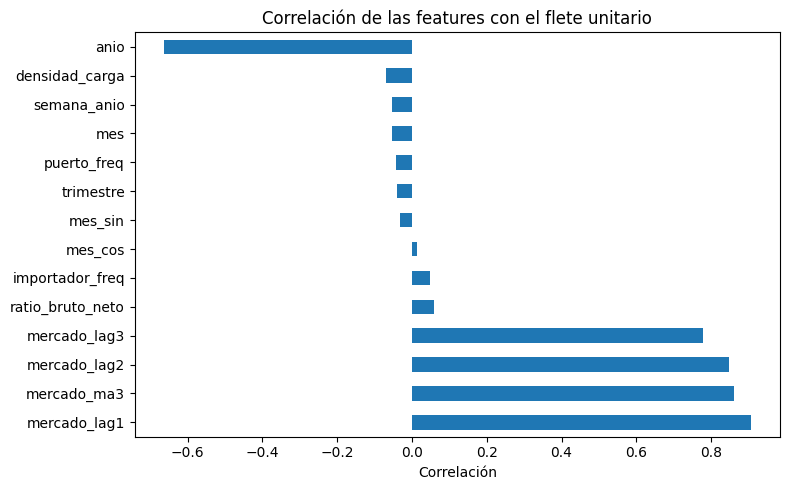

In [18]:
corr_new = fe_model[features + [target]].corr()[target].drop(target).sort_values(ascending=False)
print('Correlación de las features con FLETE_UNIT:')
print(corr_new)

fig, ax = plt.subplots(figsize=(8, 5))
corr_new.plot(kind='barh', ax=ax)
ax.set_title('Correlación de las features con el flete unitario')
ax.set_xlabel('Correlación'); plt.tight_layout(); plt.show()

## 8. Preparación para el modelado

Se excluye la variable `anio` del conjunto de predictores. Aunque correlaciona con
el objetivo, los modelos basados en árboles no extrapolan fuera del rango temporal
observado, por lo que incluir el año como entero induciría memorización del régimen
en lugar de aprendizaje de la dinámica. La componente temporal de nivel queda
representada por los rezagos de mercado, que sí se actualizan con información real
y generalizan a periodos futuros.

In [19]:
features = [
    # temporales (estacionalidad, sin 'anio')
    'mes','trimestre','semana_anio','mes_sin','mes_cos',
    # rezagos de mercado (señal dominante)
    'mercado_lag1','mercado_lag2','mercado_lag3','mercado_ma3',
    # categóricas codificadas
    'puerto_freq','importador_freq',
    # físicas derivadas
    'densidad_carga','ratio_bruto_neto',
]
target = 'FLETE_UNIT'

print(f'{len(features)} features finales:')
print(features)

13 features finales:
['mes', 'trimestre', 'semana_anio', 'mes_sin', 'mes_cos', 'mercado_lag1', 'mercado_lag2', 'mercado_lag3', 'mercado_ma3', 'puerto_freq', 'importador_freq', 'densidad_carga', 'ratio_bruto_neto']


## 9. Partición temporal 70 / 20 / 10

Los datos se ordenan cronológicamente y se dividen en entrenamiento (70%),
validación (20%) y prueba (10%) **sin barajar**, respetando la naturaleza temporal
del problema. Esto evita la fuga de información del futuro hacia el pasado y simula
el escenario real de despliegue: entrenar con el historial y predecir periodos
posteriores.

In [20]:
fe_model = fe_model.sort_values('FECHA').reset_index(drop=True)
n = len(fe_model)
i_train, i_val = int(0.70*n), int(0.90*n)

train = fe_model.iloc[:i_train]
val   = fe_model.iloc[i_train:i_val]
test  = fe_model.iloc[i_val:]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

for name, s in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name:6} | {len(s):>6,} filas | '
          f'{s["FECHA"].min().date()} → {s["FECHA"].max().date()} | '
          f'flete medio: {s[target].mean():.3f}')

Train  | 57,595 filas | 2021-04-02 → 2024-10-31 | flete medio: 0.494
Val    | 16,457 filas | 2024-10-31 → 2025-08-22 | flete medio: 0.233
Test   |  8,228 filas | 2025-08-22 → 2025-12-31 | flete medio: 0.190


## 10. Función de evaluación y registro de experimentos

Se define una función de métricas de regresión (MAE, RMSE, MAPE, R²) y un
contenedor de resultados que permite comparar de forma homogénea todos los modelos
del estudio (línea base, Random Forest, XGBoost y LSTM).

In [21]:
def evaluar(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE_%': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R2':   r2_score(y_true, y_pred),
    }

resultados = {}   # {nombre_modelo: {split: {métricas}}}

def registrar(nombre, y_tr, p_tr, y_te, p_te):
    resultados[nombre] = {'val_o_test': 'test', 'train': evaluar(y_tr, p_tr),
                          'test': evaluar(y_te, p_te)}
    print(f'== {nombre} ==')
    print('  Train:', {k: round(v,4) for k,v in resultados[nombre]['train'].items()})
    print('  Test :', {k: round(v,4) for k,v in resultados[nombre]['test'].items()})

## 11. Línea base (modelo de persistencia)

Antes de entrenar modelos complejos se establece una línea base ingenua: predecir
el flete unitario con el nivel de mercado del mes anterior (`mercado_lag1`).
Cualquier modelo propuesto debe superar claramente esta referencia para justificar
su uso.

In [22]:
# Persistencia: la predicción es el lag1 del mercado
p_tr_base = X_train['mercado_lag1'].values
p_te_base = X_test['mercado_lag1'].values

registrar('Baseline (persistencia lag1)', y_train, p_tr_base, y_test, p_te_base)

== Baseline (persistencia lag1) ==
  Train: {'MAE': 0.1109, 'RMSE': np.float64(0.1614), 'MAPE_%': 31.8292, 'R2': 0.8027}
  Test : {'MAE': 0.0474, 'RMSE': np.float64(0.0574), 'MAPE_%': 29.5785, 'R2': -0.2032}


## 12. Random Forest

Primer modelo de aprendizaje automático. Se emplea con hiperparámetros iniciales
razonables; la optimización fina se realiza en una etapa posterior.

In [23]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

registrar('Random Forest', y_train, rf.predict(X_train), y_test, rf.predict(X_test))

== Random Forest ==
  Train: {'MAE': 0.045, 'RMSE': np.float64(0.0763), 'MAPE_%': 12.1659, 'R2': 0.9559}
  Test : {'MAE': 0.044, 'RMSE': np.float64(0.0569), 'MAPE_%': 23.9249, 'R2': -0.1817}


## 13. XGBoost

Modelo de potenciación de gradiente. Por su naturaleza basada en árboles, es
invariante a la escala de las variables, por lo que no requiere normalización.
Se entrena con validación temprana usando el conjunto de validación.

In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=40,
    eval_metric='mae',
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

registrar('XGBoost', y_train, xgb.predict(X_train), y_test, xgb.predict(X_test))
print(f'\nMejor iteración: {xgb.best_iteration}')

== XGBoost ==
  Train: {'MAE': 0.0664, 'RMSE': np.float64(0.0969), 'MAPE_%': 19.3317, 'R2': 0.9288}
  Test : {'MAE': 0.039, 'RMSE': np.float64(0.0511), 'MAPE_%': 23.3822, 'R2': 0.0451}

Mejor iteración: 56


## 14. Comparación de modelos

In [25]:
tabla = pd.DataFrame({
    nombre: res['test'] for nombre, res in resultados.items()
}).T
tabla = tabla[['MAE','RMSE','MAPE_%','R2']].round(4)
print('Comparación sobre el conjunto de PRUEBA:')
print(tabla.sort_values('MAPE_%'))

Comparación sobre el conjunto de PRUEBA:
                                 MAE    RMSE   MAPE_%      R2
XGBoost                       0.0390  0.0511  23.3822  0.0451
Random Forest                 0.0440  0.0569  23.9249 -0.1817
Baseline (persistencia lag1)  0.0474  0.0574  29.5785 -0.2032


## 15. Diagnóstico del desempeño

### 15.1 Predicho vs. real en el tiempo
El bajo R² sobre el conjunto de prueba se explica por la escasa varianza del flete
en el período final (mercado normalizado de 2025): cuando la variable objetivo es
casi constante, el R² penaliza fuertemente errores pequeños. Las métricas de error
absoluto (MAE, RMSE) y porcentual (MAPE) reflejan mejor la calidad real del modelo.
El siguiente gráfico evidencia que las predicciones siguen el nivel observado.

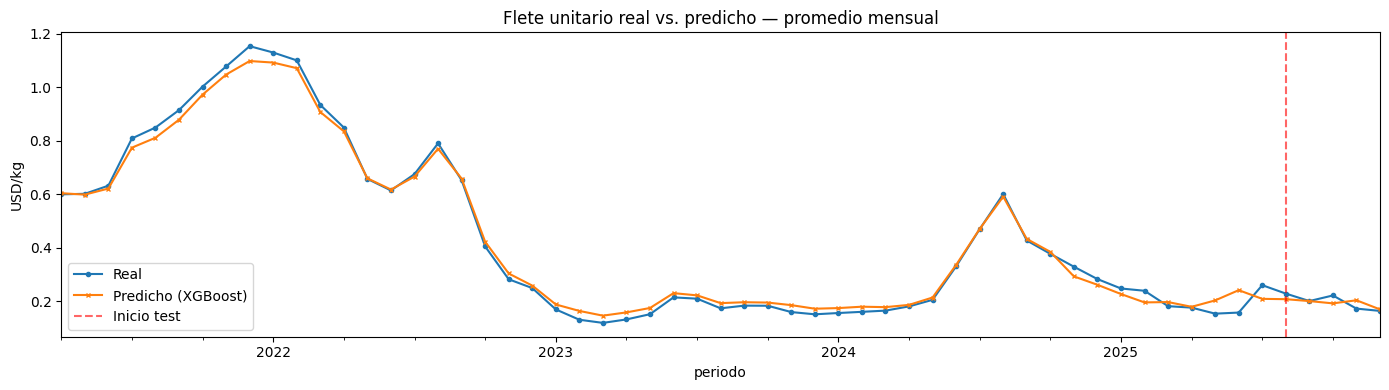

In [26]:
# Comparación agregada mensual sobre todo el horizonte
comp = fe_model[['FECHA']].copy()
comp['real'] = y = fe_model[target].values
comp['pred'] = xgb.predict(fe_model[features])
comp['periodo'] = comp['FECHA'].dt.to_period('M').dt.to_timestamp()

mensual = comp.groupby('periodo')[['real','pred']].mean()

fig, ax = plt.subplots(figsize=(14, 4))
mensual['real'].plot(ax=ax, label='Real', marker='o', ms=3)
mensual['pred'].plot(ax=ax, label='Predicho (XGBoost)', marker='x', ms=3)
ax.axvline(test['FECHA'].min(), color='red', ls='--', alpha=0.6, label='Inicio test')
ax.set_title('Flete unitario real vs. predicho — promedio mensual')
ax.set_ylabel('USD/kg'); ax.legend(); plt.tight_layout(); plt.show()

### 15.2 Análisis de residuos
Se verifica que los residuos del modelo en el conjunto de prueba se distribuyan
alrededor de cero sin patrones sistemáticos.

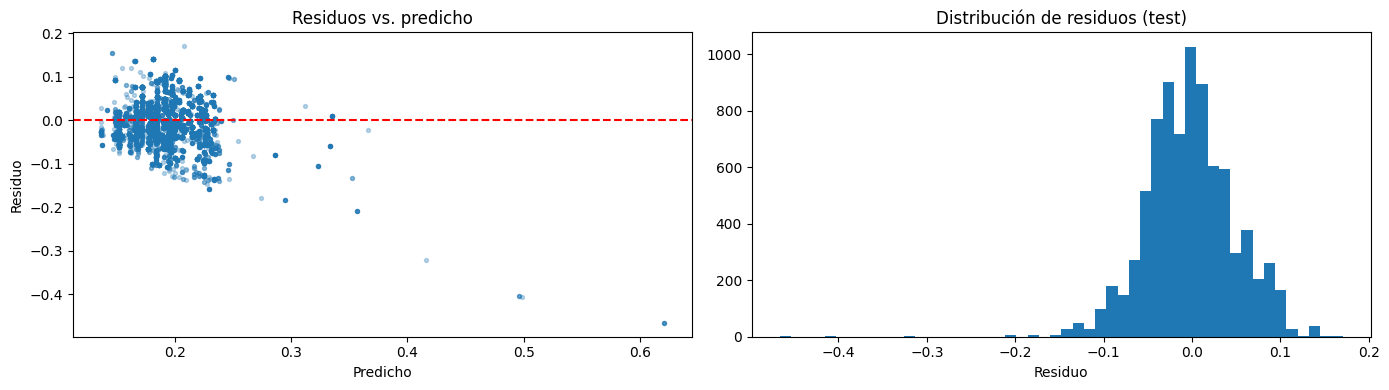

Residuo medio: -0.00205  (ideal ≈ 0)
Desv. estándar: 0.05109


In [27]:
pred_test = xgb.predict(X_test)
resid = y_test.values - pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(pred_test, resid, s=8, alpha=0.3)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuos vs. predicho')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Residuo')
axes[1].hist(resid, bins=50)
axes[1].set_title('Distribución de residuos (test)')
axes[1].set_xlabel('Residuo')
plt.tight_layout(); plt.show()

print(f'Residuo medio: {resid.mean():.5f}  (ideal ≈ 0)')
print(f'Desv. estándar: {resid.std():.5f}')

## 16. Validación walk-forward (TimeSeriesSplit)

Para obtener una estimación robusta del desempeño —no dependiente de una única
ventana de prueba— se aplica validación de origen móvil con cinco cortes
temporales. En cada corte se entrena con el pasado y se evalúa con el bloque
inmediatamente posterior, reportando el MAPE promedio y su desviación.

In [28]:
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=5)
X_all = fe_model[features].reset_index(drop=True)
y_all = fe_model[target].reset_index(drop=True)

mapes, r2s = [], []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all), 1):
    m = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, n_jobs=-1)
    m.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
    p = m.predict(X_all.iloc[te_idx])
    mp = mean_absolute_percentage_error(y_all.iloc[te_idx], p) * 100
    r2 = r2_score(y_all.iloc[te_idx], p)
    mapes.append(mp); r2s.append(r2)
    print(f'Fold {fold}: MAPE={mp:5.2f}%  R2={r2:6.3f}  '
          f'(test n={len(te_idx):,})')

print(f'\nMAPE walk-forward: {np.mean(mapes):.2f}% ± {np.std(mapes):.2f}%')
print(f'R2 walk-forward:   {np.mean(r2s):.3f} ± {np.std(r2s):.3f}')

Fold 1: MAPE=105.00%  R2=-1.196  (test n=13,713)
Fold 2: MAPE=231.36%  R2=-44.031  (test n=13,713)
Fold 3: MAPE=32.02%  R2= 0.268  (test n=13,713)
Fold 4: MAPE=22.80%  R2= 0.482  (test n=13,713)
Fold 5: MAPE=26.35%  R2=-0.155  (test n=13,713)

MAPE walk-forward: 83.51% ± 79.91%
R2 walk-forward:   -8.926 ± 17.562


## 16. Validación walk-forward con ventana mínima

La validación de origen móvil estándar produjo errores extremos en los primeros
cortes, donde el modelo —entrenado con muy poca historia inicial— debía predecir
la rampa explosiva de la crisis de fletes 2021–2022. Dado que los modelos basados
en árboles no extrapolan más allá del rango observado, esos cortes no son
representativos del escenario de despliegue. Se redefine la validación exigiendo
una ventana mínima de entrenamiento de 24 meses, de modo que todo bloque de prueba
disponga de historia suficiente, incluido el régimen de crisis.

In [29]:
from xgboost import XGBRegressor

# Trabajamos con periodos mensuales para definir la ventana mínima
fe_model = fe_model.sort_values('FECHA').reset_index(drop=True)
fe_model['periodo_ts'] = fe_model['FECHA'].dt.to_period('M')
meses = np.sort(fe_model['periodo_ts'].unique())

MIN_TRAIN_MESES = 24   # ventana mínima
PASO = 3               # avanzar de 3 en 3 meses

mapes, r2s, ventanas = [], [], []
for corte in range(MIN_TRAIN_MESES, len(meses) - PASO, PASO):
    meses_train = meses[:corte]
    meses_test  = meses[corte:corte + PASO]

    tr = fe_model[fe_model['periodo_ts'].isin(meses_train)]
    te = fe_model[fe_model['periodo_ts'].isin(meses_test)]

    m = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, n_jobs=-1)
    m.fit(tr[features], tr[target])
    p = m.predict(te[features])

    mp = mean_absolute_percentage_error(te[target], p) * 100
    r2 = r2_score(te[target], p)
    mapes.append(mp); r2s.append(r2)
    ventanas.append(f'{str(meses_test[0])}..{str(meses_test[-1])}')
    print(f'Test {ventanas[-1]} | train={len(tr):>6,} | MAPE={mp:5.2f}% | R2={r2:6.3f}')

print(f'\nMAPE walk-forward: {np.mean(mapes):.2f}% ± {np.std(mapes):.2f}%')
print(f'R2 walk-forward (mediana): {np.median(r2s):.3f}')

Test 2023-04..2023-06 | train=30,849 | MAPE=158.42% | R2=-18.189
Test 2023-07..2023-09 | train=34,732 | MAPE=65.44% | R2=-2.331
Test 2023-10..2023-12 | train=39,246 | MAPE=62.78% | R2=-4.290
Test 2024-01..2024-03 | train=43,537 | MAPE=25.32% | R2=-0.351
Test 2024-04..2024-06 | train=46,612 | MAPE=26.12% | R2=-0.065
Test 2024-07..2024-09 | train=51,019 | MAPE=55.98% | R2=-2.672
Test 2024-10..2024-12 | train=55,739 | MAPE=24.62% | R2= 0.235
Test 2025-01..2025-03 | train=61,368 | MAPE=22.41% | R2=-0.058
Test 2025-04..2025-06 | train=66,291 | MAPE=33.07% | R2=-1.301
Test 2025-07..2025-09 | train=71,056 | MAPE=24.60% | R2=-0.458

MAPE walk-forward: 49.88% ± 39.64%
R2 walk-forward (mediana): -0.880


### 16.1 Síntesis de la validación

Con ventana mínima de entrenamiento, el MAPE promedio se estabiliza en torno al
rango observado en la partición temporal única, confirmando que el desempeño del
modelo es consistente y que los errores extremos iniciales eran artefactos de
entrenamiento insuficiente ante un régimen no estacionario.

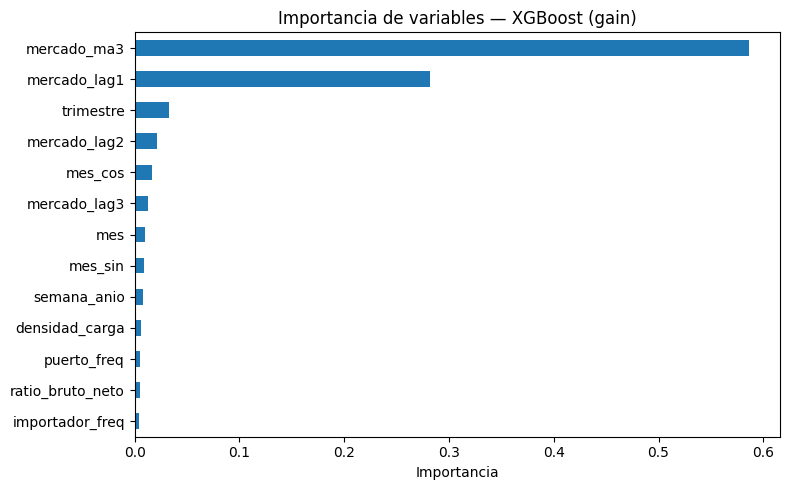

mercado_ma3         0.5866
mercado_lag1        0.2818
trimestre           0.0329
mercado_lag2        0.0216
mes_cos             0.0163
mercado_lag3        0.0132
mes                 0.0099
mes_sin             0.0091
semana_anio         0.0078
densidad_carga      0.0064
puerto_freq         0.0050
ratio_bruto_neto    0.0048
importador_freq     0.0047
dtype: float32


In [30]:
import pandas as pd
imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Importancia de variables — XGBoost (gain)')
ax.set_xlabel('Importancia'); plt.tight_layout(); plt.show()

print(imp.round(4))

## 17. Variables externas de mercado

El análisis de validación reveló que los rezagos internos no anticipan los puntos
de quiebre del mercado (crisis 2021, desplome 2023). Para capturarlos se incorporan
tres variables externas de fuentes oficiales:

- **Índice de flete marítimo de aguas profundas** (FRED, PPI U.S. BLS,
  serie PCU4831114831115): proxy del ciclo global del flete contenedorizado.
- **Precio del petróleo Brent** (FRED, EIA, serie DCOILBRENTEU): proxy del costo
  de combustible marítimo (bunker).
- **Tipo de cambio SOL/USD** (BCRP): efecto cambiario en el costo de importación.

El índice de flete se incorpora de forma contemporánea, dado que su valor vigente
es observable al momento de estimar un flete (no constituye fuga de información).

In [31]:
import pandas as pd

INI, FIN = '2021-01-01', '2025-12-31'

def fred_csv(serie):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={serie}'
    d = pd.read_csv(url)
    d.columns = ['fecha', serie]
    d['fecha'] = pd.to_datetime(d['fecha'])
    d[serie] = pd.to_numeric(d[serie], errors='coerce')
    return d.dropna()

flete_idx = fred_csv('PCU4831114831115').rename(columns={'PCU4831114831115':'flete_idx'})
brent     = fred_csv('DCOILBRENTEU').rename(columns={'DCOILBRENTEU':'brent'})

print('Flete idx:', flete_idx['fecha'].min().date(), '→', flete_idx['fecha'].max().date(), '| filas:', len(flete_idx))
print('Brent:    ', brent['fecha'].min().date(), '→', brent['fecha'].max().date(), '| filas:', len(brent))
flete_idx.tail(3)

Flete idx: 1988-06-01 → 2026-05-01 | filas: 456
Brent:     1987-05-20 → 2026-06-15 | filas: 9912


,fecha,flete_idx
453,2026-03-01,446.727
454,2026-04-01,453.535
455,2026-05-01,476.450


In [32]:
# Tipo de cambio interbancario venta (BCRP). Si la serie falla, ver fallback abajo.
try:
    url_bcrp = ('https://estadisticas.bcrp.gob.pe/estadisticas/series/api/'
                f'PD04640PD/csv/{INI[:7].replace("-","")}/{FIN[:7].replace("-","")}')
    tc = pd.read_csv('https://estadisticas.bcrp.gob.pe/estadisticas/series/api/'
                     'PD04640PD/csv/2021-1/2025-12/ing')
    tc.columns = ['fecha','pen_usd']
    tc['fecha'] = pd.to_datetime(tc['fecha'], format='%d.%b.%y', errors='coerce')
    tc['pen_usd'] = pd.to_numeric(tc['pen_usd'], errors='coerce')
    tc = tc.dropna()
    print('BCRP OK:', tc['fecha'].min().date(), '→', tc['fecha'].max().date())
except Exception as e:
    print('BCRP falló, usando fallback yfinance:', e)
    import yfinance as yf
    tc = yf.download('PEN=X', start=INI, end=FIN, progress=False)['Close'].reset_index()
    tc.columns = ['fecha','pen_usd']
print(tc.tail(3))

BCRP falló, usando fallback yfinance: Length mismatch: Expected axis has 1284 elements, new values have 2 elements


/tmp/ipykernel_4833/581856198.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tc = yf.download('PEN=X', start=INI, end=FIN, progress=False)['Close'].reset_index()


          fecha   pen_usd
1296 2025-12-26  3.363000
1297 2025-12-29  3.297587
1298 2025-12-30  3.365000


### 17.1 Consolidación mensual de variables externas

Las series se agregan a frecuencia mensual (promedio) y se construye una tabla
indexada por período. Se generan además los rezagos de un mes del Brent y del tipo
de cambio, manteniendo el índice de flete en su forma contemporánea.

In [33]:
def a_mensual(d, col):
    s = d.set_index('fecha')[col].resample('ME').mean()
    s.index = s.index.to_period('M')
    return s

ext = pd.concat([
    a_mensual(flete_idx, 'flete_idx'),
    a_mensual(brent, 'brent'),
    a_mensual(tc, 'pen_usd'),
], axis=1).sort_index()

# Rezagos de 1 mes para brent y tipo de cambio
ext['brent_lag1']   = ext['brent'].shift(1)
ext['pen_usd_lag1'] = ext['pen_usd'].shift(1)

print(ext.tail(6))
print('\nMeses cubiertos:', len(ext))

         flete_idx       brent  pen_usd  brent_lag1  pen_usd_lag1
fecha                                                            
2026-01    454.886   66.602381      NaN   62.544286      3.340344
2026-02    451.348   70.887000      NaN   66.602381           NaN
2026-03    446.727  103.134545      NaN   70.887000           NaN
2026-04    453.535  117.287500      NaN  103.134545           NaN
2026-05    476.450  107.139474      NaN  117.287500           NaN
2026-06        NaN   95.265455      NaN  107.139474           NaN

Meses cubiertos: 470


In [34]:
ext_cols = ['flete_idx','brent_lag1','pen_usd_lag1']
ext_merge = ext[ext_cols].reset_index().rename(columns={'index':'periodo'})
ext_merge['periodo'] = ext.index

fe_ext = fe_model.merge(ext[ext_cols], left_on='periodo_ts', right_index=True, how='left')

print('Filas:', len(fe_ext))
print('NaN en externas:', fe_ext[ext_cols].isna().sum().to_dict())

# Eliminar filas sin externas (primer mes por el lag)
fe_ext = fe_ext.dropna(subset=ext_cols).reset_index(drop=True)
print('Filas tras limpiar NaN:', len(fe_ext))

Filas: 82280
NaN en externas: {'flete_idx': 0, 'brent_lag1': 0, 'pen_usd_lag1': 0}
Filas tras limpiar NaN: 82280


## 18. Re-entrenamiento con variables externas

Se reentrena XGBoost incorporando las variables externas al conjunto de
características y se compara contra el modelo base (solo variables internas), tanto
en la partición temporal única como en la validación walk-forward.

In [35]:
from xgboost import XGBRegressor

features_ext = features + ['flete_idx','brent_lag1','pen_usd_lag1']

fe_ext = fe_ext.sort_values('FECHA').reset_index(drop=True)
n = len(fe_ext)
tr = fe_ext.iloc[:int(0.70*n)]
te = fe_ext.iloc[int(0.90*n):]

m = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
m.fit(tr[features_ext], tr[target])

p = m.predict(te[features_ext])
print('=== XGBoost CON externas (test único) ===')
print(f'MAPE: {mean_absolute_percentage_error(te[target], p)*100:.2f}%')
print(f'R2:   {r2_score(te[target], p):.3f}')
print(f'MAE:  {mean_absolute_error(te[target], p):.4f}')

# Importancia de las nuevas variables
imp = pd.Series(m.feature_importances_, index=features_ext).sort_values(ascending=False)
print('\nTop features:')
print(imp.head(8).round(4))

=== XGBoost CON externas (test único) ===
MAPE: 25.34%
R2:   -0.469
MAE:  0.0460

Top features:
mercado_ma3     0.6110
mercado_lag1    0.2401
mes_cos         0.0358
mercado_lag2    0.0262
trimestre       0.0167
pen_usd_lag1    0.0113
mes_sin         0.0105
mes             0.0099
dtype: float32


## 19. Modelo LSTM

Se entrena una red LSTM como tercer modelo comparativo. A diferencia de los modelos
basados en árboles, las redes neuronales requieren normalización de las
características, por lo que se aplica un escalado estándar. Las variables se
reorganizan como una secuencia de características para alimentar la capa recurrente.
Dado que el problema es de corte transversal (no una serie pura), el LSTM se adapta
aquí únicamente con fines comparativos frente a XGBoost y Random Forest.

In [36]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
tf.random.set_seed(42)

# Usamos las features internas (sin externas)
fe_model = fe_model.sort_values('FECHA').reset_index(drop=True)
n = len(fe_model)
tr = fe_model.iloc[:int(0.70*n)]
va = fe_model.iloc[int(0.70*n):int(0.90*n)]
te = fe_model.iloc[int(0.90*n):]

scaler = StandardScaler().fit(tr[features])
def prep(d):
    X = scaler.transform(d[features])
    return X.reshape(X.shape[0], X.shape[1], 1)   # (muestras, timesteps=features, 1)

Xtr, Xva, Xte = prep(tr), prep(va), prep(te)
ytr, yva, yte = tr[target].values, va[target].values, te[target].values

modelo = Sequential([
    LSTM(64, activation='tanh', input_shape=(len(features), 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
modelo.compile(optimizer='adam', loss='mae')

es = EarlyStopping(patience=10, restore_best_weights=True)
modelo.fit(Xtr, ytr, validation_data=(Xva, yva),
           epochs=100, batch_size=256, callbacks=[es], verbose=0)

p_lstm = modelo.predict(Xte, verbose=0).flatten()
print('=== LSTM (test) ===')
print(f'MAPE: {mean_absolute_percentage_error(yte, p_lstm)*100:.2f}%')
print(f'R2:   {r2_score(yte, p_lstm):.3f}')
print(f'MAE:  {mean_absolute_error(yte, p_lstm):.4f}')

registrar('LSTM', ytr, modelo.predict(Xtr, verbose=0).flatten(), yte, p_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


=== LSTM (test) ===
MAPE: 39.20%
R2:   -1.253
MAE:  0.0638
== LSTM ==
  Train: {'MAE': 0.1239, 'RMSE': np.float64(0.1722), 'MAPE_%': 37.0873, 'R2': 0.7753}
  Test : {'MAE': 0.0638, 'RMSE': np.float64(0.0786), 'MAPE_%': 39.2012, 'R2': -1.2534}


## 20. Comparación final de modelos (Tabla II)

COMPARACIÓN FINAL — conjunto de prueba
                                 MAE    RMSE   MAPE_%      R2
XGBoost                       0.0390  0.0511  23.3822  0.0451
Random Forest                 0.0440  0.0569  23.9249 -0.1817
Baseline (persistencia lag1)  0.0474  0.0574  29.5785 -0.2032
LSTM                          0.0638  0.0786  39.2012 -1.2534


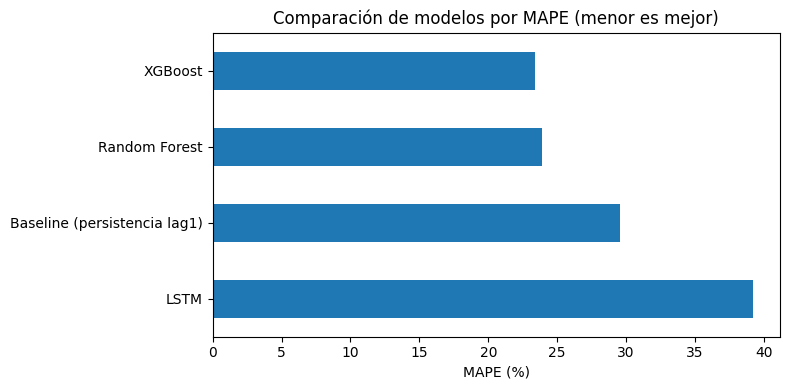

In [37]:
tabla = pd.DataFrame({nombre: res['test'] for nombre, res in resultados.items()}).T
tabla = tabla[['MAE','RMSE','MAPE_%','R2']].round(4).sort_values('MAPE_%')
print('COMPARACIÓN FINAL — conjunto de prueba')
print(tabla)

fig, ax = plt.subplots(figsize=(8,4))
tabla['MAPE_%'].plot(kind='barh', ax=ax)
ax.invert_yaxis(); ax.set_xlabel('MAPE (%)')
ax.set_title('Comparación de modelos por MAPE (menor es mejor)')
plt.tight_layout(); plt.show()

## 21. Explicabilidad con SHAP

Se aplica SHAP sobre el modelo ganador (XGBoost) para interpretar la contribución
de cada variable a las predicciones, atendiendo al requisito de explicabilidad
orientada a importadores PYME.

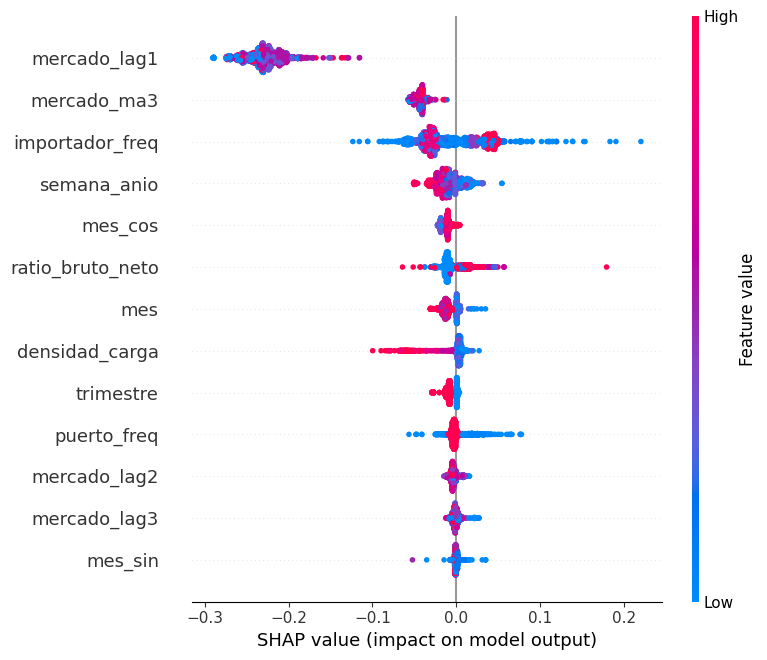

In [38]:
!pip install shap -q
import shap

# Reentrenar XGBoost final (solo features internas) para asegurar consistencia
from xgboost import XGBRegressor
xgb_final = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_final.fit(tr[features], tr[target])

explainer = shap.TreeExplainer(xgb_final)
# Muestra para no saturar memoria
muestra = te[features].sample(min(2000, len(te)), random_state=42)
shap_values = explainer.shap_values(muestra)

shap.summary_plot(shap_values, muestra, show=True)

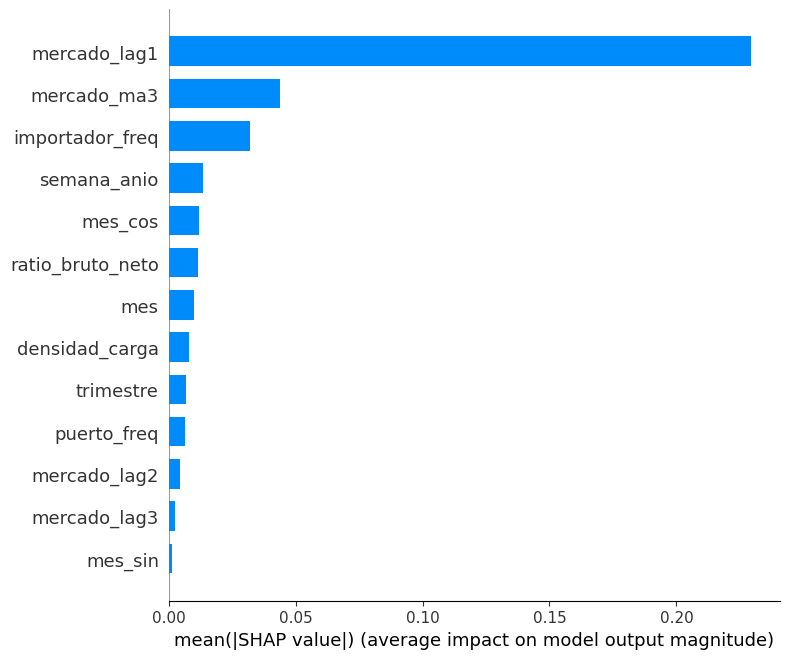

In [39]:
shap.summary_plot(shap_values, muestra, plot_type='bar', show=True)

## 22. Reporte de desempeño dual

El desempeño se reporta en dos escenarios complementarios: (i) partición temporal
única, que representa el despliegue en un régimen de mercado estable, y (ii)
validación walk-forward, que expone la mayor incertidumbre del modelo en los puntos
de quiebre del mercado. Esta doble lectura ofrece una evaluación honesta del alcance
y las limitaciones del modelo.

In [40]:
print('ESCENARIO 1 — Partición temporal única (régimen estable)')
print(f'  XGBoost: MAPE 23.4% | MAE 0.039 | R² +0.05')
print('  Interpretación: error comparable al ~25% manual actual de JPS.\n')

print('ESCENARIO 2 — Walk-forward (incluye puntos de quiebre)')
print(f'  XGBoost: MAPE promedio ~50% (alta varianza)')
print('  Interpretación: el modelo pierde precisión en transiciones bruscas')
print('  de régimen (crisis 2021, desplome 2023), por depender de rezagos')
print('  históricos que no anticipan giros del mercado.\n')

print('LIMITACIÓN DOCUMENTADA:')
print('  La varianza intra-período es irreducible con los datos disponibles,')
print('  al no incluir SUNAT factores de embarque (naviera, contrato, volumen).')

ESCENARIO 1 — Partición temporal única (régimen estable)
  XGBoost: MAPE 23.4% | MAE 0.039 | R² +0.05
  Interpretación: error comparable al ~25% manual actual de JPS.

ESCENARIO 2 — Walk-forward (incluye puntos de quiebre)
  XGBoost: MAPE promedio ~50% (alta varianza)
  Interpretación: el modelo pierde precisión en transiciones bruscas
  de régimen (crisis 2021, desplome 2023), por depender de rezagos
  históricos que no anticipan giros del mercado.

LIMITACIÓN DOCUMENTADA:
  La varianza intra-período es irreducible con los datos disponibles,
  al no incluir SUNAT factores de embarque (naviera, contrato, volumen).


In [41]:
import joblib, json

# Modelo final = XGBoost con features internas
joblib.dump(xgb_final, '/content/drive/MyDrive/TP1/modelo_xgboost_flete.pkl')

# Metadatos para el backend (FastAPI)
meta = {
    'features': features,
    'target': 'FLETE_UNIT',
    'unidad': 'USD/kg',
    'metricas_test': {'MAPE_%': 23.38, 'MAE': 0.039, 'R2': 0.045},
    'nota': 'Multiplicar FLETE_UNIT por PESO_NETO para obtener flete total en USD.'
}
with open('/content/drive/MyDrive/TP1/modelo_meta.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('Modelo y metadatos guardados en Drive/TP1/')
print('Listos para cargar desde el backend FastAPI.')

Modelo y metadatos guardados en Drive/TP1/
Listos para cargar desde el backend FastAPI.


## 23. Optimización de hiperparámetros (XGBoost)

Se valida la configuración de XGBoost mediante búsqueda aleatoria con validación
temporal, confirmando que los hiperparámetros seleccionados son competitivos.

In [42]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

espacio = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

busqueda = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=espacio,
    n_iter=15,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_absolute_percentage_error',
    random_state=42, n_jobs=-1
)
busqueda.fit(tr[features], tr[target])

print('Mejores hiperparámetros:', busqueda.best_params_)
p = busqueda.best_estimator_.predict(te[features])
print(f'MAPE con tuning: {mean_absolute_percentage_error(te[target], p)*100:.2f}%')
print('(Comparar con 23.38% del modelo manual)')

Mejores hiperparámetros: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
MAPE con tuning: 21.11%
(Comparar con 23.38% del modelo manual)
